<a href="https://colab.research.google.com/github/Agoston03/Machine-Learning-VIMIMA05/blob/main/ML_2026_lab5_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks

Last time we used an MLP to classify points in our synthetic dataset. In this notebook, we will classify traffic signs using convolutional neural networks. To do this, we will first download and then read in the data:

In [ ]:
!wget 'https://github.com/bolgarbe/gt-data/raw/master/kresz.npz'

--2024-04-10 17:45:50--  https://github.com/bolgarbe/gt-data/raw/master/kresz.npz
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/bolgarbe/gt-data/master/kresz.npz [following]
--2024-04-10 17:45:50--  https://raw.githubusercontent.com/bolgarbe/gt-data/master/kresz.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 69108046 (66M) [application/octet-stream]
Saving to: ‘kresz.npz’

kresz.npz           100%[===================>]  65.91M   247MB/s    in 0.3s    

2024-04-10 17:45:52 (247 MB/s) - ‘kresz.npz’ saved [69108046/69108046]



In [ ]:
!pip install torchviz  # similarly to the previous lab, we'll be using torchviz to inspect the computation graph constructed by pytorch

  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
  Using cached 

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

import torch

In [ ]:
data = np.load('kresz.npz')
x_train = data['x_train']
x_test  = data['x_test']
y_train = data['y_train']
y_test  = data['y_test']

The x_train variable stores the images of the training set, and the y_train variable stores the corresponding labels. Let's examine what these variables contain:

In [ ]:
# Just print the variable or use cell output (uncomment and run cell)
#x_train
#y_train

Easier to see content if you print the shape and containted data types.

In [ ]:
print(x_train.shape, x_train.dtype)
print(y_train.shape, y_train.dtype)

(4575, 32, 32, 3) float32
(4575,) int64


The `x_train` variable stores 4575 $32\times 32$ RGB images (this is $4575 \times 32 \times 32 \times 3$ real numbers between $0$ and $1$); similarly, the `y_train` variable contains 4575 labels (integer numbers between $0$ and $61$).

**Task 1.** Examine which type of traffic sign is the most and the least frequent in the training database, and draw an example of each. Use numpy functions for selecting and [plt.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) for plotting.

In [ ]:
# TODO count labels, find samples from most/least frequent, plot images

The `PyTorch` library expects the data to be wrapped in its own data type (`torch.Tensor`). For images, the data structure differs somewhat from the previous one:

Instead of (`number of samples` $\times$ `row` $\times$ `column` $\times$ `color`), it is (`number of samples` $\times$ `color` $\times$ `row` $\times$ `column`).

Therefore, when converting to a tensor, we need to rearrange the order:

In [ ]:
x_train_tensor = torch.tensor(x_train).permute(0,3,1,2)
y_train_tensor = torch.tensor(y_train)

x_test_tensor = torch.tensor(x_test).permute(0,3,1,2)
y_test_tensor = torch.tensor(y_test)

**Understanding the `device` Parameter in PyTorch**

The `device` parameter in PyTorch provides flexibility in where tensors (and consequently, your models) reside for computation. This is critical in deep learning for leveraging the strengths of both CPUs and GPUs.

**Core Considerations:**

* **CPUs:** Excel in general-purpose computing with a few fast cores and large memory. This is ideal for data loading and preprocessing.
* **GPUs:** Designed for massively parallel computations with thousands of slower cores and limited memory.  GPUs significantly accelerate the matrix multiplications and other operations at the heart of neural network training.
* **Data Transfer Overhead:**  Moving data between the CPU and GPU can introduce bottlenecks.  Efficient PyTorch workflows minimize these transfers.

Smart use of the `device` parameter lets you harness the power of GPUs for accelerated deep learning while carefully managing data movement for optimal performance.

In [ ]:
# To use cuda, we need to have a cuda compatiblye hardware
# Colab provides runtime with GPU-s for a limited period, use
# 'change runtime type' in the 'Runtime' dropdown if you
# 'torch.cuda.is_available()' is False and you want to use
# gpu
torch.cuda.is_available()

True

In [ ]:
# creating tensors, we can see the device when printing the tensor
# or with .device
tensor_on_gpu = torch.zeros(10, device='cuda')
tensor_on_cpu = torch.zeros(10)
tensor_on_gpu, tensor_on_cpu, tensor_on_cpu.device

(tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 device(type='cpu'))

In [ ]:
# no cross operations between devices
tensor_on_cpu + tensor_on_gpu
# Expected: "RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!"

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
# we can move tensor's from 1 device to an other using .to(device), .cpu() and .cuda()
tensor_on_gpu.cpu(), tensor_on_cpu.cuda(), tensor_on_cpu.to('cuda')

(tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0'))

In [ ]:
# Most python models inherit from the torch.nn.Module class. This class
# also support these methods
linear = torch.nn.Linear(3, 2)
print('subclass:', isinstance(linear, torch.nn.Module))

print('Weight matrix after creation', linear.weight)
linear.to('cuda')
print('Weight matrix after device transfer', linear.weight)

subclass: True
Weight matrix after creation Parameter containing:
tensor([[ 0.2415,  0.4453, -0.2871],
        [ 0.2688, -0.3528,  0.5058]], requires_grad=True)
Weight matrix after device transfer Parameter containing:
tensor([[ 0.2415,  0.4453, -0.2871],
        [ 0.2688, -0.3528,  0.5058]], device='cuda:0', requires_grad=True)


Specifying the hyperparameters all at once is good practice, they are easier to modify this way, than if they were hard coded into the training loop, etc.

In [ ]:
batch_size = 256
num_epochs = 10
lr = 0.01
# Good idea to start with cpu, better error messages for debugging
device = 'cpu'  # 'cuda'

**Task 2.** Create two `DataLoader` objects that will perform the division of the data into minibatches, 1 for training and 1 for testing. Ensure that the data arrives in a random order during training, but no during testing.

Documentation:
https://pytorch.org/docs/stable/data.html

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = ...
train_loader = ...

test_dataset = ...
test_loader = ...

**Task 3.** Create a convolutional neural network architecture for classifying images! (Initially just run this; later, you will need to fine-tune it to achieve the desired predictive performance.)

Documentation:

- [torch.nn.Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
- [torch.nn.Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [Non-linear activations (weighted sum, nonlinearity)](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)
- [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)

In [ ]:
net = torch.nn.Sequential(                           # [Input:                                -> (batch_size x 3 x 32 x 32)]
  torch.nn.Conv2d(3,32,(4,4),stride=2,padding=1),    # Convolutional layer                    -> (batch_size x 32 x 16 x 16)
  torch.nn.ReLU(),                                   # ReLU activation                       -> (batch_size x 32 x 16 x 16)
  torch.nn.Flatten(),                                # Flatten from 2D images to 1D vectors  -> (batch_size x 8192)
  torch.nn.Linear(8192, 62),                         # Fully connected layer for 62 labels   -> (batch_size x 62)
).to(device) # using .to(device), to transfer whole model to chosen device memory

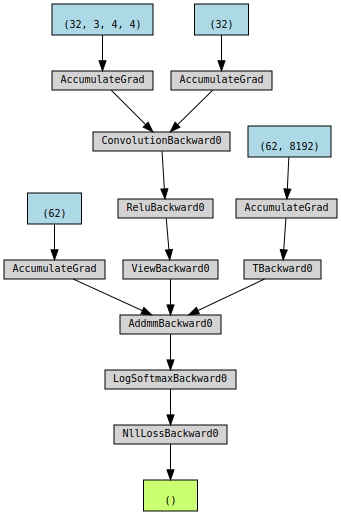

In [ ]:
import torchviz
# We can inspect the dynamically constructed computational graph
# The four parameters of our network are the bias and weights of the Conv2d
# and Linear layers
loss_fn = torch.nn.CrossEntropyLoss()
logits = net(torch.zeros(1, 3, 32, 32))
loss = loss_fn(logits, torch.tensor([0], dtype=torch.long))
torchviz.make_dot(loss)

For training the model, we select a suitable optimizer (e.g., ADAM) and define the loss function (since we are performing classification, cross-entropy should be used).

Documentation: [torch.optim.Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)

In [ ]:
from tqdm.auto import tqdm  # for a nice progress bar

optimizer = torch.optim.Adam(net.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

# Basic PyTorch training loop
net.train()                                    # Set to training mode
for epoch in tqdm(range(num_epochs), desc='Training model'):  # Iterate over the data num_epochs times
    for images, target_labels in train_loader:                # Iterate through the minibatches
        images = images.to(device)                            # Transfer the data to the correct device
        target_labels = target_labels.to(device)

        pred_logits = net(images)                             # Network output
        loss = loss_fn(pred_logits, target_labels)            # Calculate loss

        optimizer.zero_grad()                                 # Zero the gradients
        loss.backward()                                       # Calculate gradients (backpropagation)
        optimizer.step()                                      # Update model parameters

Training model:   0%|          | 0/10 [00:00<?, ?it/s]

After training, all we have to do is feed the test inputs into the network.

**Task 5.** Run the model and evaluate its predictive performance (accuracy)!

In [ ]:
pred_label_list = []

net.eval()                    # Set to eval model (e.g. disable dropout)
with torch.inference_mode():  # Similar to no_grad, but remove even more autograd functionality for even more efficiency
  pass
  # TODO collect predictions

pred_labels = torch.cat(pred_label_list).numpy()

# TODO calculate accuracy
accuracy = ...
f'Model accuracy {accuracy}'

'Model accuracy 0.9119047619047619'

**Task 6.** Demonstrate the classifier on some randomly selected images from the test set! (e.g., display the image and the predicted label).

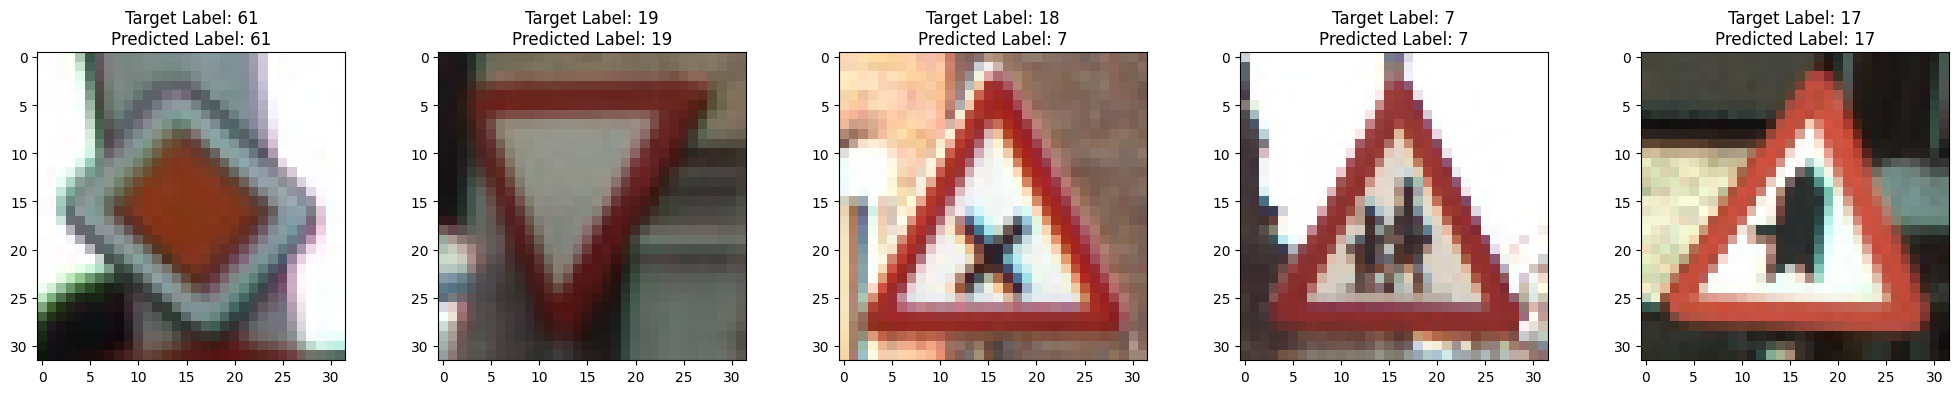

In [ ]:
# TODO choose a few examples and plot the images. Either print the target and
#  predicted classes or set the image titles.

# Homework assignment

Modify the model and training algorithm to achieve better performance

Tips:

Try out more model architectures:
 - add layers and modify layer sizes
 - use BatchNorm
 - use Dropout
 - try out different activation functions
 - use a more complex model (e.g. resnet, ViT)

Modify the training cycle:
- data augmentation with torchvision
- change the learning rate and number of epochs
- add learning rate scheduling (cosine usually does wonders)
- early stopping

Each optimization you try out is worth 2 points, but you have to achieve at least 94% accuracy to pass. Solutions with 97% get max points.

Please modify the cells above to implement you changes, but list your modifications below.

*List your chosen modifications, also write a short summary of your experiences.*

*e.g.: Added a StepLR scheduler from torch.optim.lr_scheduler, accuracy improved by 1%*